In [1]:
import pandas as pd
import numpy as np
import scipy
from scipy import stats
from scipy.linalg import norm
from pykalman.pykalman import *
import control
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set(style='white', font_scale=1.5)

# Import custom modules
import prep_emotioncon 
import emotioncon_modelling
import emotioncon_stats
import auxiliary

In [2]:
# Create instances of the Modelling and PrepData classes
emo = emotioncon_modelling.Modelling()
prep = prep_emotioncon.PrepEmotioncon()
emostats = emotioncon_stats.Statistics() 

mood_categories = ['disgusted', 'amused', 'calm', 'anxious', 'sad'] # Define the mood categories as a list
filepath = '../' # Specify the file path
debug = True  # Flag to FALSE to save files and figures

# Load data from a numpy file
data = np.load(filepath + 'results/fit_experiment.npy', allow_pickle=True)

# Process the loaded data into a DataFrame, mood ratings, and other related variables
df, mood_ratings, foo = prep.create_df_from_dict(data)

# Create inputs based on videos shown during experiment
inp = emo.input_from_videos('../experiment/public/prep/videosForExperiment.csv')

# Calculate the number of subjects based on the length of the loaded data
Nsj = len(data)
print('N = ' + str(Nsj))

N = 108


In [3]:
# Exclude participants if their estimates show outliers
ex = emostats.exclude_outliers(data, 13, 14, 'results_split')

data = np.delete(data,ex[0])
Nsj = len(data)

In [4]:
df, mood_ratings, foo = prep.create_df_from_dict(data)

Simulate data based on estimated parameters from the most parsimonious model
--

In [5]:
# Get the number of time points from the first subject's ratings data
T = np.shape(data[0]['ratings'])[1]

# Set the number of times to simulated and re-fit data
nruns = 100

# Loop through each subject
for sj in range(Nsj):
    # Create empty arrays to store the simulation results for each subject
    z, x = np.empty((T, 5, nruns)), np.empty((T, 5, nruns))
    
    # Loop through each time point (before and after intervention)
    for t in range(2):
        # Split the input data for the current time point
        inp_split = inp[t*int(T/2):t*int(T/2) + int(T/2), :]
        
        # Loop through each run
        for i in range(nruns):
            # Perform the simulation and store the results in the 'x' array
            foo, x[t*int(T/2):t*int(T/2) + int(T/2), :, i] = \
            data[sj]['results_split'][13+t].sample(int(T/2), initial_state=data[sj]['ratings'][:,t*int(T/2)], \
                                                    control_inputs=inp_split)
        
        # Store the simulation results for the current subject in the 'simulated' field of the data dictionary
        data[sj]['simulated'] = x

if debug == False:
    np.save(filepath + 'results/fit_experiment_recovery' + str(nruns) + ' .npy', data)

Fit simulated data
--

In [78]:
from tqdm import tqdm

# Initialize the number of runs
nruns = data[0]['simulated'].shape[2]

# Calculate total iterations
total_iterations = Nsj * nruns

# Create a single progress bar
pbar = tqdm(total=total_iterations, desc="Processing")

# Loop through each subject
for sj in range(Nsj):
    # Create an empty list to store recovery results for each run
    data[sj]['recovery'] = []
    
    # Loop through each run
    for i in range(nruns):
        # Update progress bar description
        pbar.set_description(f"Subject {sj+1}/{Nsj}, Run {i+1}/{nruns}")
        
        # Create an empty list to store the Kalman filter results for each time point (before and after intervention)
        results = []
        
        # Extract the data to fit for this run
        data_to_fit = data[sj]['simulated'][:, :, i]
        T = np.shape(data_to_fit)[0]
        
        # Define Kalman filter options
        opt = emo.define_kf_options(data_to_fit, inp)
        opt['em_vars'] = emo.parameter_short(['A', 'C', 'S', 'G'])
        ll_split = 0
        
        # Loop through each time point (before and after intervention)
        for t in range(2):
            # Split the mood ratings and inputs for the current time point
            mood_ratings_split = data_to_fit[t*int(T/2):t*int(T/2) + int(T/2), :]
            inputs_split = inp[t*int(T/2):t*int(T/2) + int(T/2), :]
            
            # Update Kalman filter options with the current inputs
            opt['inp'] = inputs_split 
            
            # Run the Kalman filter
            kf = emo.run_KF(mood_ratings_split, opt)
            results.append(kf)
    
        # Append the results for this run to the subject's recovery list
        data[sj]['recovery'].append(results)
        
        # Update progress bar
        pbar.update(1)

# Close progress bar
pbar.close()

if debug == False:
    np.save(filepath + 'results/fit_experiment_recovery' + str(nruns) + ' .npy', data)

Subject 104/104, Run 100/100: 100%|█████| 10400/10400 [6:29:35<00:00,  2.25s/it]


Calculate recovery metrics per subject
---

In [5]:
nruns = 100
data = np.load(filepath + 'results/fit_experiment_recovery' + str(nruns) + ' .npy', allow_pickle=True)

In [6]:
def extract_kf_parameters(kf):
    """Extract parameters from Kalman filter output object."""
    params_dict = {}
    
    if hasattr(kf, 'transition_matrices'):
        params_dict['A'] = kf.transition_matrices.flatten()
        params_dict['A_matrix'] = kf.transition_matrices
    
    if hasattr(kf, 'observation_matrices'):
        params_dict['C'] = kf.control_matrix.flatten()
        params_dict['C_matrix'] = kf.control_matrix
        params_dict['C_norm'] = norm(kf.control_matrix, 'fro')
    
    if hasattr(kf, 'transition_covariance'):
        params_dict['S'] = np.diag(kf.transition_covariance)
    
    if hasattr(kf, 'observation_covariance'):
        params_dict['G'] = np.diag(kf.observation_covariance)
    
    # Eigenspectrum
    if hasattr(kf, 'transition_matrices'):
        from scipy.linalg import eig
        eigenvalues, eigenvectors = eig(kf.transition_matrices)
        dominant_idx = np.argmax(np.abs(eigenvalues))
        params_dict['dominant_eigenvalue'] = eigenvalues[dominant_idx]
        params_dict['dominant_eigenvalue_magnitude'] = np.abs(eigenvalues[dominant_idx])
        params_dict['dominant_eigenvector'] = eigenvectors[:, dominant_idx]
    
    # Controllability
    if hasattr(kf, 'transition_matrices') and hasattr(kf, 'control_matrix'):
        import control
        from scipy.linalg import svd
        A = kf.transition_matrices
        C = kf.control_matrix
        controllability_matrix = control.ctrb(A, C)
        params_dict['controllability_norm'] = norm(controllability_matrix, 'fro')
        U, s, Vh = svd(controllability_matrix, full_matrices=False)
        params_dict['dominant_singular_value'] = s[0]
        params_dict['dominant_left_singular_vector'] = U[:, 0]
    
    return params_dict


def calculate_per_subject_recovery_metrics(data, Nsj, Nsim, time_period_idx):
    """
    Calculate recovery metrics per subject (across all simulations).
    
    For each subject:
    - Calculate correlation between true and recovered parameters across all simulations
    - Store mean AND SD to capture within-subject variability
    
    Returns:
    --------
    per_subject_metrics : dict
        Metrics for each subject (lists of length Nsj)
        Each entry contains both mean and std for that subject
    """
    
    # Initialize storage for per-subject metrics
    per_subject_metrics = {
        'A_corr': [],
        'A_corr_std': [],
        'C_corr': [],
        'C_corr_std': [],
        'S_corr': [],
        'S_corr_std': [],
        'G_corr': [],
        'G_corr_std': [],
        'dom_eigvec_corr': [],
        'dom_eigvec_corr_std': [],
        'dom_eigvec_dot': [],
        'dom_eigvec_dot_std': [],
        'dom_lsv_corr': [],
        'dom_lsv_corr_std': [],
        'dom_lsv_dot': [],
        'dom_lsv_dot_std': [],
    }
    
    # Also store raw values for scatter plots (pooled across subjects and simulations)
    pooled_raw = {
        'dom_eigval_mag_true': [],
        'dom_eigval_mag_rec': [],
        'dom_sv_true': [],
        'dom_sv_rec': [],
        'C_norm_true': [],
        'C_norm_rec': [],
        'ctrb_norm_true': [],
        'ctrb_norm_rec': [],
        'dom_eigvec_corr': [],
        'dom_eigvec_dot': [],
        'dom_lsv_corr': [],
        'dom_lsv_dot': [],
    }
    
    # Loop through each subject
    for sj in range(Nsj):
        # Get true parameters once for this subject
        true_kf = data[sj]['results_split'][13 + time_period_idx]
        true_params = extract_kf_parameters(true_kf)
        
        # Collect correlations across all simulations for this subject
        A_corr_sj = []
        C_corr_sj = []
        S_corr_sj = []
        G_corr_sj = []
        dom_eigvec_corr_sj = []
        dom_eigvec_dot_sj = []
        dom_lsv_corr_sj = []
        dom_lsv_dot_sj = []
        
        for sim_idx in range(Nsim):
            rec_kf = data[sj]['recovery'][sim_idx][time_period_idx]
            rec_params = extract_kf_parameters(rec_kf)
            
            # Element-wise correlation for matrices (per simulation)
            A_corr_sj.append(np.corrcoef(true_params['A'], rec_params['A'])[0, 1])
            C_corr_sj.append(np.corrcoef(true_params['C'], rec_params['C'])[0, 1])
            
            if 'S' in true_params and 'S' in rec_params:
                S_corr_sj.append(np.corrcoef(true_params['S'], rec_params['S'])[0, 1])
            
            if 'G' in true_params and 'G' in rec_params:
                G_corr_sj.append(np.corrcoef(true_params['G'], rec_params['G'])[0, 1])
            
            # Calculate eigenvector alignment for this simulation
            dom_eigvec_true = true_params['dominant_eigenvector']
            dom_eigvec_rec = rec_params['dominant_eigenvector']
            
            if np.iscomplexobj(dom_eigvec_true) or np.iscomplexobj(dom_eigvec_rec):
                corr_val = np.abs(np.corrcoef(np.real(dom_eigvec_true), np.real(dom_eigvec_rec))[0, 1])
                vec_true_norm = dom_eigvec_true / (np.linalg.norm(dom_eigvec_true) + 1e-10)
                vec_rec_norm = dom_eigvec_rec / (np.linalg.norm(dom_eigvec_rec) + 1e-10)
                dot_val = np.abs(np.vdot(vec_true_norm, vec_rec_norm))
            else:
                corr_val = np.abs(np.corrcoef(dom_eigvec_true, dom_eigvec_rec)[0, 1])
                vec_true_norm = dom_eigvec_true / (np.linalg.norm(dom_eigvec_true) + 1e-10)
                vec_rec_norm = dom_eigvec_rec / (np.linalg.norm(dom_eigvec_rec) + 1e-10)
                dot_val = np.abs(np.dot(vec_true_norm, vec_rec_norm))
            
            dom_eigvec_corr_sj.append(corr_val)
            dom_eigvec_dot_sj.append(dot_val)
            
            # Left singular vector alignment
            dom_lsv_true = true_params['dominant_left_singular_vector']
            dom_lsv_rec = rec_params['dominant_left_singular_vector']
            lsv_corr_val = np.abs(np.corrcoef(dom_lsv_true, dom_lsv_rec)[0, 1])
            lsv_true_norm = dom_lsv_true / (np.linalg.norm(dom_lsv_true) + 1e-10)
            lsv_rec_norm = dom_lsv_rec / (np.linalg.norm(dom_lsv_rec) + 1e-10)
            lsv_dot_val = np.abs(np.dot(lsv_true_norm, lsv_rec_norm))
            dom_lsv_corr_sj.append(lsv_corr_val)
            dom_lsv_dot_sj.append(lsv_dot_val)
            
            # Store for pooled raw values
            pooled_raw['dom_eigval_mag_true'].append(true_params['dominant_eigenvalue_magnitude'])
            pooled_raw['dom_eigval_mag_rec'].append(rec_params['dominant_eigenvalue_magnitude'])
            pooled_raw['dom_sv_true'].append(true_params['dominant_singular_value'])
            pooled_raw['dom_sv_rec'].append(rec_params['dominant_singular_value'])
            pooled_raw['C_norm_true'].append(true_params['C_norm'])
            pooled_raw['C_norm_rec'].append(rec_params['C_norm'])
            pooled_raw['ctrb_norm_true'].append(true_params['controllability_norm'])
            pooled_raw['ctrb_norm_rec'].append(rec_params['controllability_norm'])
            pooled_raw['dom_eigvec_corr'].append(corr_val)
            pooled_raw['dom_eigvec_dot'].append(dot_val)
            pooled_raw['dom_lsv_corr'].append(lsv_corr_val)
            pooled_raw['dom_lsv_dot'].append(lsv_dot_val)
        
        # Calculate mean and SD for this subject across simulations
        per_subject_metrics['A_corr'].append(np.mean(A_corr_sj))
        per_subject_metrics['A_corr_std'].append(np.std(A_corr_sj))
        
        per_subject_metrics['C_corr'].append(np.mean(C_corr_sj))
        per_subject_metrics['C_corr_std'].append(np.std(C_corr_sj))
        
        if len(S_corr_sj) > 0:
            per_subject_metrics['S_corr'].append(np.mean(S_corr_sj))
            per_subject_metrics['S_corr_std'].append(np.std(S_corr_sj))
        
        if len(G_corr_sj) > 0:
            per_subject_metrics['G_corr'].append(np.mean(G_corr_sj))
            per_subject_metrics['G_corr_std'].append(np.std(G_corr_sj))
        
        per_subject_metrics['dom_eigvec_corr'].append(np.mean(dom_eigvec_corr_sj))
        per_subject_metrics['dom_eigvec_corr_std'].append(np.std(dom_eigvec_corr_sj))
        per_subject_metrics['dom_eigvec_dot'].append(np.mean(dom_eigvec_dot_sj))
        per_subject_metrics['dom_eigvec_dot_std'].append(np.std(dom_eigvec_dot_sj))
        
        per_subject_metrics['dom_lsv_corr'].append(np.mean(dom_lsv_corr_sj))
        per_subject_metrics['dom_lsv_corr_std'].append(np.std(dom_lsv_corr_sj))
        per_subject_metrics['dom_lsv_dot'].append(np.mean(dom_lsv_dot_sj))
        per_subject_metrics['dom_lsv_dot_std'].append(np.std(dom_lsv_dot_sj))
    
    # Remove empty lists
    per_subject_metrics = {k: v for k, v in per_subject_metrics.items() if len(v) > 0}
    
    return per_subject_metrics, pooled_raw


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

# Determine number of simulations from data
Nsim = len(data[0]['recovery'])
print(f"Detected {Nsim} simulations per subject")

# Calculate per-subject metrics
print(f"Calculating per-subject metrics across {Nsim} simulations for {Nsj} subjects...")
metrics_pre, pooled_raw_pre = calculate_per_subject_recovery_metrics(data, Nsj, Nsim, time_period_idx=0)
metrics_post, pooled_raw_post = calculate_per_subject_recovery_metrics(data, Nsj, Nsim, time_period_idx=1)

# Combine pooled raw values for scatter plots
pooled_raw_combined = {}
for key in pooled_raw_pre.keys():
    pooled_raw_combined[key] = pooled_raw_pre[key] + pooled_raw_post[key]

# Total number of samples for scatter plots
N_total = 2 * Nsj * Nsim
print(f"Total observations for scatter plots: {N_total} ({Nsj} subjects × {Nsim} simulations × 2 periods)")
print(f"Per-subject metrics calculated across {Nsim} simulations")

# Calculate differences for bias metrics (using pooled raw values)
diff_eigval = [pooled_raw_combined['dom_eigval_mag_rec'][i] - pooled_raw_combined['dom_eigval_mag_true'][i] 
               for i in range(N_total)]
diff_sv = [pooled_raw_combined['dom_sv_rec'][i] - pooled_raw_combined['dom_sv_true'][i] 
           for i in range(N_total)]

Detected 100 simulations per subject
Calculating per-subject metrics across 100 simulations for 104 subjects...
Total observations for scatter plots: 20800 (104 subjects × 100 simulations × 2 periods)
Per-subject metrics calculated across 100 simulations


In [7]:
# ============================================================================
# Summary Statistics Table
# ============================================================================

print("\n" + "="*80)
print("RECOVERY SUMMARY (Per-Subject Correlations Across Simulations)")
print("="*80)

# Combine pre and post for overall statistics
combined_metrics = {}
for key in metrics_pre.keys():
    combined_metrics[key] = metrics_pre[key] + metrics_post[key]

# Display main correlation metrics
summary_stats = {}
param_display_names = {
    'A_corr': 'A Matrix',
    'C_corr': 'C Matrix',
    'S_corr': 'S Diagonal',
    'G_corr': 'G Diagonal',
    'dom_eigvec_corr': 'Dominant Eigenvector',
    'dom_lsv_corr': 'Dominant Left SV'
}

for key, name in param_display_names.items():
    if key in combined_metrics:
        summary_stats[name] = combined_metrics[key]

print(f"\n{'Parameter':<25} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Pass (>0.7)':<15}")
print("-"*80)
for param, values in summary_stats.items():
    vals = np.array(values)
    n_pass = np.sum(vals >= 0.7)
    n_total_subjects = len(vals)
    print(f"{param:<25} {np.mean(vals):<10.3f} {np.std(vals):<10.3f} "
          f"{np.min(vals):<10.3f} {np.max(vals):<10.3f} {n_pass}/{n_total_subjects} ({100*n_pass/n_total_subjects:.1f}%)")

print("\n" + "="*80)
print("SCALAR VALUE RECOVERY (Across-Subject Correlations)")
print("="*80)

# Calculate across-subject correlations for scalar values
eigval_corr = np.corrcoef(pooled_raw_combined['dom_eigval_mag_true'], pooled_raw_combined['dom_eigval_mag_rec'])[0, 1]
sv_corr = np.corrcoef(pooled_raw_combined['dom_sv_true'], pooled_raw_combined['dom_sv_rec'])[0, 1]
C_norm_corr = np.corrcoef(pooled_raw_combined['C_norm_true'], pooled_raw_combined['C_norm_rec'])[0, 1]
ctrb_norm_corr = np.corrcoef(pooled_raw_combined['ctrb_norm_true'], pooled_raw_combined['ctrb_norm_rec'])[0, 1]

print(f"\n{'Parameter':<30} {'Correlation':<15} {'Mean Bias':<15}")
print("-"*80)
print(f"{'Dominant Eigenvalue Magnitude':<30} {eigval_corr:<15.3f} {np.mean(diff_eigval):<15.3f}")
print(f"{'Dominant Singular Value':<30} {sv_corr:<15.3f} {np.mean(diff_sv):<15.1f}")
print(f"{'C Matrix Norm':<30} {C_norm_corr:<15.3f} {np.mean([pooled_raw_combined['C_norm_rec'][i] - pooled_raw_combined['C_norm_true'][i] for i in range(N_total)]):<15.1f}")
print(f"{'Controllability Matrix Norm':<30} {ctrb_norm_corr:<15.3f} {np.mean([pooled_raw_combined['ctrb_norm_rec'][i] - pooled_raw_combined['ctrb_norm_true'][i] for i in range(N_total)]):<15.1f}")

print("\n" + "="*80)
print("DOT PRODUCT METRICS (Per-Subject Means)")
print("="*80)

dot_stats = {}
if 'dom_eigvec_dot' in combined_metrics:
    dot_stats['Dominant Eigenvector'] = combined_metrics['dom_eigvec_dot']
if 'dom_lsv_dot' in combined_metrics:
    dot_stats['Dominant Left SV'] = combined_metrics['dom_lsv_dot']

print(f"\n{'Parameter':<25} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Pass (>0.8)':<15}")
print("-"*80)
for param, values in dot_stats.items():
    vals = np.array(values)
    n_pass = np.sum(vals >= 0.8)
    n_total_subjects = len(vals)
    print(f"{param:<25} {np.mean(vals):<10.3f} {np.std(vals):<10.3f} "
          f"{np.min(vals):<10.3f} {np.max(vals):<10.3f} {n_pass}/{n_total_subjects} ({100*n_pass/n_total_subjects:.1f}%)")

print("\n" + "="*80)
print("VARIABILITY DECOMPOSITION TABLE")
print("="*80)
print("\nShowing both WITHIN-subject (across 100 simulations) and ACROSS-subject variability")
print("Combined Pre+Post data (N = 208 subject-period observations)")

# Combine pre and post metrics
combined_metrics_full = {}
for key in metrics_pre.keys():
    if key in metrics_post:
        combined_metrics_full[key] = metrics_pre[key] + metrics_post[key]

# Create comprehensive table
print("\n" + "-"*100)
print(f"{'Parameter':<25} {'Mean':<12} {'Across-Subj':<15} {'Within-Subj':<15} {'Total':<15}")
print(f"{'':25} {'(r or |dot|)':<12} {'SD':<15} {'Mean SD':<15} {'Variability':<15}")
print("-"*100)

# Correlation metrics
correlation_params = [
    ('A_corr', 'A_corr_std', 'A Matrix'),
    ('C_corr', 'C_corr_std', 'C Matrix'),
    ('S_corr', 'S_corr_std', 'S Diagonal'),
    ('G_corr', 'G_corr_std', 'G Diagonal'),
    ('dom_eigvec_corr', 'dom_eigvec_corr_std', 'Dom. Eigenvector (r)'),
    ('dom_lsv_corr', 'dom_lsv_corr_std', 'Dom. Left SV (r)'),
]

for mean_key, std_key, name in correlation_params:
    if mean_key in combined_metrics_full and std_key in combined_metrics_full:
        means = np.array(combined_metrics_full[mean_key])
        stds = np.array(combined_metrics_full[std_key])
        
        grand_mean = np.mean(means)
        across_subj_sd = np.std(means)
        within_subj_mean_sd = np.mean(stds)
        total_var = np.sqrt(across_subj_sd**2 + within_subj_mean_sd**2)
        
        print(f"{name:<25} {grand_mean:<12.3f} {across_subj_sd:<15.3f} {within_subj_mean_sd:<15.3f} {total_var:<15.3f}")

# Dot product metrics
dot_product_params = [
    ('dom_eigvec_dot', 'dom_eigvec_dot_std', 'Dom. Eigenvector (dot)'),
    ('dom_lsv_dot', 'dom_lsv_dot_std', 'Dom. Left SV (dot)'),
]

for mean_key, std_key, name in dot_product_params:
    if mean_key in combined_metrics_full and std_key in combined_metrics_full:
        means = np.array(combined_metrics_full[mean_key])
        stds = np.array(combined_metrics_full[std_key])
        
        grand_mean = np.mean(means)
        across_subj_sd = np.std(means)
        within_subj_mean_sd = np.mean(stds)
        total_var = np.sqrt(across_subj_sd**2 + within_subj_mean_sd**2)
        
        print(f"{name:<25} {grand_mean:<12.3f} {across_subj_sd:<15.3f} {within_subj_mean_sd:<15.3f} {total_var:<15.3f}")

print("-"*100)
print("\nInterpretation:")
print("  - Mean: Average recovery quality across all subjects")
print("  - Across-Subj SD: Variability between different subjects")
print("  - Within-Subj Mean SD: Average variability within each subject across 100 simulations")
print("  - Total Variability: Combined estimate (sqrt of sum of variances)")

print("\n" + "="*80)
print("PRE vs POST COMPARISON TABLE")
print("="*80)
print("\nShowing Mean (Across-Subj SD) [Within-Subj Mean SD]")

print("\n" + "-"*90)
print(f"{'Parameter':<30} {'Pre-Intervention':<30} {'Post-Intervention':<30}")
print("-"*90)

for mean_key, std_key, name in correlation_params + dot_product_params:
    if mean_key in metrics_pre and mean_key in metrics_post:
        # Pre
        pre_means = np.array(metrics_pre[mean_key])
        pre_stds = np.array(metrics_pre[std_key])
        pre_grand_mean = np.mean(pre_means)
        pre_across_sd = np.std(pre_means)
        pre_within_sd = np.mean(pre_stds)
        
        # Post
        post_means = np.array(metrics_post[mean_key])
        post_stds = np.array(metrics_post[std_key])
        post_grand_mean = np.mean(post_means)
        post_across_sd = np.std(post_means)
        post_within_sd = np.mean(post_stds)
        
        pre_str = f"{pre_grand_mean:.3f} ({pre_across_sd:.3f}) [{pre_within_sd:.3f}]"
        post_str = f"{post_grand_mean:.3f} ({post_across_sd:.3f}) [{post_within_sd:.3f}]"
        
        print(f"{name:<30} {pre_str:<30} {post_str:<30}")

print("-"*90)


print("\n" + "="*80)
print("BIAS METRICS (From pooled scatter plot data)")
print("="*80)

# Calculate bias metrics from pooled raw data
C_norm_bias = [(pooled_raw_combined['C_norm_rec'][i] - pooled_raw_combined['C_norm_true'][i]) / pooled_raw_combined['C_norm_true'][i] * 100 
               for i in range(N_total)]
ctrb_norm_bias = [(pooled_raw_combined['ctrb_norm_rec'][i] - pooled_raw_combined['ctrb_norm_true'][i]) / pooled_raw_combined['ctrb_norm_true'][i] * 100 
                  for i in range(N_total)]

print(f"C Matrix Norm - Mean Abs % Bias: {np.mean(np.abs(C_norm_bias)):.2f}%")
print(f"Controllability Matrix Norm - Mean Abs % Bias: {np.mean(np.abs(ctrb_norm_bias)):.2f}%")
print(f"Dominant Eigenvalue - Mean Bias: {np.mean(diff_eigval):.3f} (SD: {np.std(diff_eigval):.3f})")
print(f"Dominant Singular Value - Mean Bias: {np.mean(diff_sv):.1f} (SD: {np.std(diff_sv):.1f})")

print("\n" + "="*80)
print("VARIANCE DECOMPOSITION INTERPRETATION GUIDE")
print("="*80)

print("\nThe variability in parameter recovery has two sources:")
print("\n1. WITHIN-SUBJECT VARIABILITY (Across 100 simulations)")
print("   - How much does recovery vary for the SAME subject with different data realizations?")
print("   - Reflects stochastic variability in the data generation and fitting process")
print("   - Low values → Stable recovery for a given subject")
print("   - High values → Recovery is sensitive to random noise")

print("\n2. ACROSS-SUBJECT VARIABILITY")
print("   - How much does recovery quality differ BETWEEN subjects?")  
print("   - Reflects subject-level heterogeneity in parameter identifiability")
print("   - Low values → All subjects recover equally well")
print("   - High values → Some subjects are easier to recover than others")

print("\n3. TOTAL VARIABILITY")
print("   - Combined estimate: sqrt(across-subject variance + within-subject variance)")
print("   - Overall uncertainty in a single recovery attempt for a random subject")

print("\nIDEAL PATTERN:")
print("   - Low within-subject SD → Reliable recovery given enough data")
print("   - Low across-subject SD → Consistent quality across population")
print("   - High mean correlation + low total variability → Robust recovery")

print("\nCONCERNING PATTERN:")
print("   - High within-subject SD → Recovery unstable even for same subject")
print("   - High across-subject SD → Quality control needed (some subjects fail)")
print("   - Low mean correlation → Systematic identifiability issues")

print("\n" + "="*80)


RECOVERY SUMMARY (Per-Subject Correlations Across Simulations)

Parameter                 Mean       Std        Min        Max        Pass (>0.7)    
--------------------------------------------------------------------------------
A Matrix                  0.741      0.183      -0.065     0.953      153/208 (73.6%)
C Matrix                  0.715      0.278      -0.769     0.973      143/208 (68.8%)
S Diagonal                0.456      0.209      -0.297     0.973      20/208 (9.6%)
G Diagonal                0.595      0.320      -0.499     1.000      101/208 (48.6%)
Dominant Eigenvector      0.771      0.137      0.273      0.971      143/208 (68.8%)
Dominant Left SV          0.826      0.157      0.101      0.994      168/208 (80.8%)

SCALAR VALUE RECOVERY (Across-Subject Correlations)

Parameter                      Correlation     Mean Bias      
--------------------------------------------------------------------------------
Dominant Eigenvalue Magnitude  0.723           0.009    

/var/folders/5z/t44r3krd25sftrcjrj8j__4m0000gn/T/ipykernel_313/1289410412.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(param_labels, size=15)


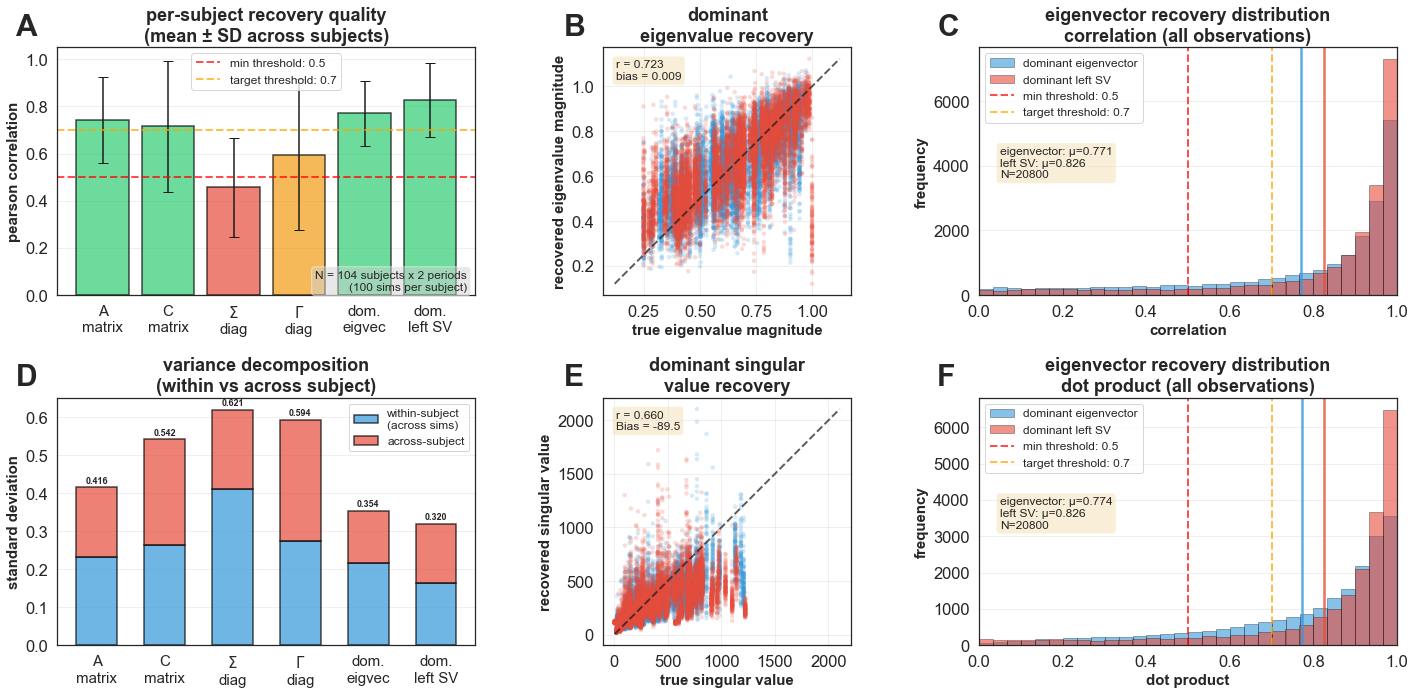

In [8]:
# Define colors for scatter plots (used in multiple panels)
colors_pre = ['#3498db'] * (Nsj * Nsim)
colors_post = ['#e74c3c'] * (Nsj * Nsim)
colors_all = colors_pre + colors_post

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ============================================================================
# Panel A: Correlation by parameter type (per-subject mean ± SD)
# ============================================================================
ax = axes[0, 0]

# Determine which parameters we have
param_labels = []
param_means = []
param_stds = []

# Combine pre and post for overall statistics
for param_name, label in [('A_corr', 'A\nmatrix'), ('C_corr', 'C\nmatrix'), 
                           ('S_corr', '$\Sigma$\ndiag'), ('G_corr', '$\Gamma$\ndiag'),
                           ('dom_eigvec_corr', 'dom.\neigvec'), ('dom_lsv_corr', 'dom.\nleft SV')]:
    if param_name in metrics_pre and param_name in metrics_post:
        combined_vals = metrics_pre[param_name] + metrics_post[param_name]
        param_labels.append(label)
        param_means.append(np.mean(combined_vals))
        param_stds.append(np.std(combined_vals))

# Color by quality
colors = ['#2ecc71' if m >= 0.7 else '#f39c12' if m >= 0.5 else '#e74c3c' for m in param_means]

bars = ax.bar(param_labels, param_means, yerr=param_stds, capsize=5, 
              color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xticklabels(param_labels, size=15)
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='min threshold: 0.5', alpha=0.7)
ax.axhline(0.7, color='orange', linestyle='--', linewidth=2, label='target threshold: 0.7', alpha=0.7)
ax.set_ylabel('pearson correlation', fontsize=15, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.set_title('per-subject recovery quality\n(mean ± SD across subjects)', fontsize=18, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add sample size annotation
ax.text(0.98, 0.02, f'N = {Nsj} subjects x 2 periods\n({Nsim} sims per subject)',
        transform=ax.transAxes, fontsize=12, ha='right',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

ax.text(-0.1, 1.05, 'A', transform=ax.transAxes, weight='bold', size=30)

# ============================================================================
# Panel B: True vs Recovered for Dominant Eigenvalue Magnitude
# ============================================================================
ax = axes[0, 1]

ax.scatter(pooled_raw_combined['dom_eigval_mag_true'], pooled_raw_combined['dom_eigval_mag_rec'], 
           alpha=0.2, s=20, c=colors_all, edgecolors='none')

# Identity line
eigval_lims = [min(pooled_raw_combined['dom_eigval_mag_true'] + pooled_raw_combined['dom_eigval_mag_rec']),
               max(pooled_raw_combined['dom_eigval_mag_true'] + pooled_raw_combined['dom_eigval_mag_rec'])]
ax.plot(eigval_lims, eigval_lims, 'k--', linewidth=2, alpha=0.7, label='perfect recovery')

# Calculate correlation
eigval_corr = np.corrcoef(pooled_raw_combined['dom_eigval_mag_true'], pooled_raw_combined['dom_eigval_mag_rec'])[0, 1]
mean_bias = np.mean(diff_eigval)

ax.set_xlabel('true eigenvalue magnitude', fontsize=15, fontweight='bold')
ax.set_ylabel('recovered eigenvalue magnitude', fontsize=15, fontweight='bold')
ax.set_title('dominant\neigenvalue recovery', fontsize=18, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# Add text box with metrics
ax.text(0.05, 0.95, f'r = {eigval_corr:.3f}\nbias = {mean_bias:.3f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.text(-0.16, 1.05, 'B', transform=ax.transAxes, weight='bold', size=30)

# ============================================================================
# Panel C: Eigenvector Recovery Quality Distribution (correlation)
# ============================================================================
ax = axes[0, 2]

# Show histogram of eigenvector correlations
eigvec_corr_all = pooled_raw_combined['dom_eigvec_corr']
lsv_corr_all = pooled_raw_combined['dom_lsv_corr']

# Create overlapping histograms
ax.hist(eigvec_corr_all, bins=30, alpha=0.6, color='#3498db', 
        edgecolor='black', linewidth=0.5, label='dominant eigenvector')
ax.hist(lsv_corr_all, bins=30, alpha=0.6, color='#e74c3c', 
        edgecolor='black', linewidth=0.5, label='dominant left SV')

# Add threshold lines
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='min threshold: 0.5')
ax.axvline(0.7, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='target threshold: 0.7')

# Add mean lines
ax.axvline(np.mean(eigvec_corr_all), color='#3498db', linestyle='-', linewidth=2.5, alpha=0.8)
ax.axvline(np.mean(lsv_corr_all), color='#e74c3c', linestyle='-', linewidth=2.5, alpha=0.8)

ax.set_xlabel('correlation', fontsize=15, fontweight='bold')
ax.set_ylabel('frequency', fontsize=15, fontweight='bold')
ax.set_title('eigenvector recovery distribution\ncorrelation (all observations)', fontsize=18, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_xlim([0, 1])

# Add statistics text box
text_str = (f'eigenvector: μ={np.mean(eigvec_corr_all):.3f}\n'
           f'left SV: μ={np.mean(lsv_corr_all):.3f}\n'
           f'N={N_total}')
ax.text(0.05, 0.6, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.text(-0.1, 1.05, 'C', transform=ax.transAxes, weight='bold', size=30)

# ============================================================================
# Panel D: Variance Decomposition
# ============================================================================
ax = axes[1, 0]

# Get parameters that have both mean and std
param_keys_var = []
param_labels_var = []
across_subj_sds = []
within_subj_sds = []

combined_metrics_full = {}
for key in metrics_pre.keys():
    if key in metrics_post:
        combined_metrics_full[key] = metrics_pre[key] + metrics_post[key]

for mean_key, std_key, name in [('A_corr', 'A_corr_std', 'A\nmatrix'), 
                                 ('C_corr', 'C_corr_std', 'C\nmatrix'),
                                ('S_corr', 'S_corr_std', '$\Sigma$\ndiag'),
                                ('G_corr', 'G_corr_std', '$\Gamma$\ndiag'),
                                 ('dom_eigvec_corr', 'dom_eigvec_corr_std', 'dom.\neigvec'),
                                 ('dom_lsv_corr', 'dom_lsv_corr_std', 'dom.\nleft SV')]:
    if mean_key in combined_metrics_full and std_key in combined_metrics_full:
        means = np.array(combined_metrics_full[mean_key])
        stds = np.array(combined_metrics_full[std_key])
        
        across_subj_sd = np.std(means)
        within_subj_mean_sd = np.mean(stds)
        
        param_labels_var.append(name)
        across_subj_sds.append(across_subj_sd)
        within_subj_sds.append(within_subj_mean_sd)

x = np.arange(len(param_labels_var))
width = 0.6

# Stacked bars
p1 = ax.bar(x, within_subj_sds, width, label='within-subject\n(across sims)', 
            color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
p2 = ax.bar(x, across_subj_sds, width, bottom=within_subj_sds,
            label='across-subject', color='#e74c3c', alpha=0.7, 
            edgecolor='black', linewidth=1.5)

ax.set_ylabel('standard deviation', fontsize=15, fontweight='bold')
ax.set_title('variance decomposition\n(within vs across subject)', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(param_labels_var, size=15)
ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add total height labels on top
for i, (within, across) in enumerate(zip(within_subj_sds, across_subj_sds)):
    total = within + across
    ax.text(i, total + 0.005, f'{total:.3f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=9)
    
ax.text(-0.1, 1.05, 'D', transform=ax.transAxes, weight='bold', size=30)

# ============================================================================
# Panel E: True vs Recovered for Dominant Singular Value
# ============================================================================
ax = axes[1, 1]

ax.scatter(pooled_raw_combined['dom_sv_true'], pooled_raw_combined['dom_sv_rec'], 
           alpha=0.2, s=20, c=colors_all, edgecolors='none')

# Identity line
sv_lims = [min(pooled_raw_combined['dom_sv_true'] + pooled_raw_combined['dom_sv_rec']),
           max(pooled_raw_combined['dom_sv_true'] + pooled_raw_combined['dom_sv_rec'])]
ax.plot(sv_lims, sv_lims, 'k--', linewidth=2, alpha=0.7, label='perfect recovery')

# Calculate correlation
sv_corr = np.corrcoef(pooled_raw_combined['dom_sv_true'], pooled_raw_combined['dom_sv_rec'])[0, 1]
mean_bias_sv = np.mean(diff_sv)

ax.set_xlabel('true singular value', fontsize=15, fontweight='bold')
ax.set_ylabel('recovered singular value', fontsize=15, fontweight='bold')
ax.set_title('dominant singular\nvalue recovery', fontsize=18, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# Add text box with metrics
ax.text(0.05, 0.95, f'r = {sv_corr:.3f}\nBias = {mean_bias_sv:.1f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.text(-0.16, 1.05, 'E', transform=ax.transAxes, weight='bold', size=30)

# ============================================================================
# Panel F: Eigenvector Recovery Quality Distribution (dot product)
# ============================================================================
ax = axes[1, 2]

# Show histogram of eigenvector correlations
eigvec_dot_all = pooled_raw_combined['dom_eigvec_dot']
lsv_dot_all = pooled_raw_combined['dom_lsv_dot']

# Create overlapping histograms
ax.hist(eigvec_dot_all, bins=30, alpha=0.6, color='#3498db', 
        edgecolor='black', linewidth=0.5, label='dominant eigenvector')
ax.hist(lsv_dot_all, bins=30, alpha=0.6, color='#e74c3c', 
        edgecolor='black', linewidth=0.5, label='dominant left SV')

# Add threshold lines
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='min threshold: 0.5')
ax.axvline(0.7, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='target threshold: 0.7')

# Add mean lines
ax.axvline(np.mean(eigvec_dot_all), color='#3498db', linestyle='-', linewidth=2.5, alpha=0.8)
ax.axvline(np.mean(lsv_dot_all), color='#e74c3c', linestyle='-', linewidth=2.5, alpha=0.8)

ax.set_xlabel('dot product', fontsize=15, fontweight='bold')
ax.set_ylabel('frequency', fontsize=15, fontweight='bold')
ax.set_title('eigenvector recovery distribution\ndot product (all observations)', fontsize=18, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_xlim([0, 1])

# Add statistics text box
text_str = (f'eigenvector: μ={np.mean(eigvec_dot_all):.3f}\n'
           f'left SV: μ={np.mean(lsv_dot_all):.3f}\n'
           f'N={N_total}')
ax.text(0.05, 0.6, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(-0.1, 1.05, 'F', transform=ax.transAxes, weight='bold', size=30)
    
plt.tight_layout()
plt.show()

if debug == False:
    plt.savefig('parameter_recovery_overall.pdf', dpi=300, bbox_inches='tight')

Main effect recovery
---

In [11]:
# MANOVA of left singular eigenvector controllability matrix: interaction effect condition x time(per/post)
from statsmodels.multivariate.manova import MANOVA

def run_manova(data, df, sim_idx):
    Nsj = len(data)
    
    df_test = []

    # Add time 0 data
    for i in range(Nsj):  # For each subject
        row = {
            'subject_id': i,
            'time': 0,
            'condition': df['randomized_condition'].iloc[i]
        }

        rec_kf   = data[i]['recovery'][sim_idx][0]
        params   = extract_kf_parameters(rec_kf)
        lsv      = np.abs(params['dominant_left_singular_vector'])

        # Add emotion values
        for k, emotion in enumerate(mood_categories):
            row[emotion] = lsv[k]
        df_test.append(row)

    # Add time 1 data
    for i in range(Nsj):  # For each subject
        row = {
            'subject_id': i,
            'time': 1,
            'condition': df['randomized_condition'].iloc[i]
        }

        rec_kf   = data[i]['recovery'][sim_idx][1]
        params   = extract_kf_parameters(rec_kf)
        lsv      = np.abs(params['dominant_left_singular_vector'])
        # Add emotion values
        for k, emotion in enumerate(mood_categories):
            row[emotion] = lsv[k]
        df_test.append(row)

    # Convert to DataFrame
    df_test = pd.DataFrame(df_test)

    # Ensure proper data types
    df_test['time'] = df_test['time'].astype('category')
    df_test['condition'] = df_test['condition'].astype('category')
    df_test['subject_id'] = df_test['subject_id'].astype('category')

    # Perform MANOVA with proper repeated measures structure
    try:
        fit = MANOVA.from_formula('disgusted + amused + calm + anxious + sad ~ C(condition) * C(time)', 
                                 data=df_test)
        sf = fit.mv_test().summary_frame
        interaction_p = sf.loc[("C(condition):C(time)", "Wilks' lambda"), "Pr > F"]
        interaction_wilks = sf.loc[("C(condition):C(time)", "Wilks' lambda"), "Value"]
        interaction_F = sf.loc[("C(condition):C(time)", "Wilks' lambda"), "F Value"]
    except Exception as e:
        print(f"MANOVA failed: {e}")
        print("Data shape:", df_test.shape)
        print("Data types:", df_test.dtypes)

    return interaction_p, interaction_wilks, interaction_F

=== MANOVA interaction effect (condition × time) across recovery simulations ===
Wilks' λ:  mean=0.950 ± 0.019  [0.908, 0.991]
F:         mean=2.132 ± 0.824
p < 0.05:  43.0% of simulations
p < 0.01:  16.0% of simulations
median p:  0.0835


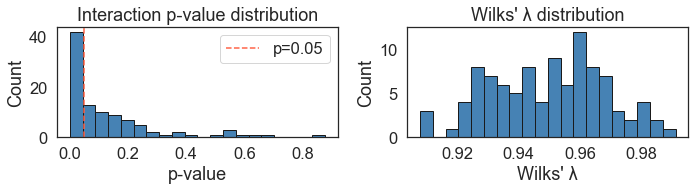

In [12]:
interaction_effect = {'p': [], 'w': [], 'F': []}

for sim_idx in range(Nsim):
    p, w, F = run_manova(data, df, sim_idx)
    interaction_effect['p'].append(p)
    interaction_effect['w'].append(w)
    interaction_effect['F'].append(F)
    
p_arr = np.array(interaction_effect['p'])
w_arr = np.array(interaction_effect['w'])
F_arr = np.array(interaction_effect['F'])

print("=== MANOVA interaction effect (condition × time) across recovery simulations ===")
print(f"Wilks' λ:  mean={np.mean(w_arr):.3f} ± {np.std(w_arr):.3f}  "
      f"[{np.min(w_arr):.3f}, {np.max(w_arr):.3f}]")
print(f"F:         mean={np.mean(F_arr):.3f} ± {np.std(F_arr):.3f}")
print(f"p < 0.05:  {np.mean(p_arr < 0.05)*100:.1f}% of simulations")
print(f"p < 0.01:  {np.mean(p_arr < 0.01)*100:.1f}% of simulations")
print(f"median p:  {np.median(p_arr):.4f}")

# Plot distribution
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(p_arr, bins=20, edgecolor='k', color='steelblue')
axes[0].axvline(0.05, color='tomato', linestyle='--', label='p=0.05')
axes[0].set_xlabel("p-value"); axes[0].set_ylabel("Count")
axes[0].set_title("Interaction p-value distribution"); axes[0].legend()

axes[1].hist(w_arr, bins=20, edgecolor='k', color='steelblue')
axes[1].set_xlabel("Wilks' λ"); axes[1].set_ylabel("Count")
axes[1].set_title("Wilks' λ distribution")

plt.tight_layout()
plt.show()

In [13]:
def stats_group_difference(data: np.array, df: pd.DataFrame) -> tuple:
    """
    Calculate group differences and perform statistical tests.
    Args:
        data (ndarray): Data matrix.
        df (DataFrame): DataFrame containing condition information.
    Returns:
        DataFrame: Results of statistical tests.
        list: List of p-values for single item tests.
        list: List of t-values for single item tests.
    """
    pvals, tvals = [], []  # for stats between single items

    # group difference before and after
    for i in range(2):
        dd = data[:, :, i]
        T2, tstats, pval = emostats.TwoSampleT2Test(dd[:, df['randomized_condition'] == 0].T,
                                                dd[:, df['randomized_condition'] == 1].T)
        pvals.append(pval)
        tvals.append(T2)

    # change
    dd = data[:, :, 1] - data[:, :, 0]
    T2, tstats, pval = emostats.TwoSampleT2Test(dd[:, df['randomized_condition'] == 0].T,
                                            dd[:, df['randomized_condition'] == 1].T)
    pvals.append(pval)
    tvals.append(T2)
    
    return pvals, tvals

=== Hotelling T² group difference recovery across simulations ===

  PRE
  T²:       mean=6.151 ± 3.204
  p < 0.05: 4.0% of simulations
  p < 0.01: 0.0% of simulations
  median p: 0.3408

  POST
  T²:       mean=24.789 ± 7.005
  p < 0.05: 98.0% of simulations
  p < 0.01: 89.0% of simulations
  median p: 0.0007

  CHANGE (POST-PRE)
  T²:       mean=14.608 ± 5.437
  p < 0.05: 65.0% of simulations
  p < 0.01: 34.0% of simulations
  median p: 0.0200


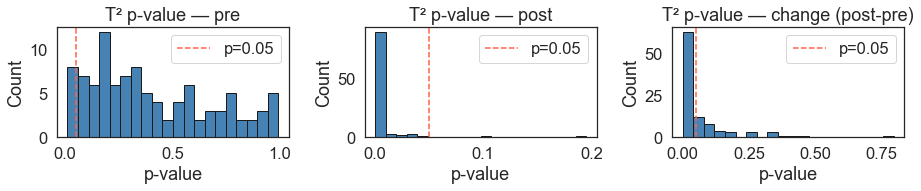

In [14]:
lsv_all = np.empty([5, Nsj, 2])
pp, tt = [], []
for sim_idx in range(Nsim):
    for sj in range(Nsj):
        for time_idx in range(2):
            rec_kf   = data[sj]['recovery'][sim_idx][time_idx]
            params   = extract_kf_parameters(rec_kf)
            lsv      = np.abs(params['dominant_left_singular_vector'])
            lsv_all[:,sj,time_idx] = lsv
    
    pvalues, tvalues = stats_group_difference(lsv_all, df)
    pp.append(pvalues)
    tt.append(tvalues)

pp_arr = np.array(pp)  # shape (Nsim, 3)
tt_arr = np.array(tt)  # shape (Nsim, 3)
labels = ['pre', 'post', 'change (post-pre)']

print("=== Hotelling T² group difference recovery across simulations ===")
for i, label in enumerate(labels):
    p = pp_arr[:, i]
    T = tt_arr[:, i]
    print(f"\n  {label.upper()}")
    print(f"  T²:       mean={np.mean(T):.3f} ± {np.std(T):.3f}")
    print(f"  p < 0.05: {np.mean(p < 0.05)*100:.1f}% of simulations")
    print(f"  p < 0.01: {np.mean(p < 0.01)*100:.1f}% of simulations")
    print(f"  median p: {np.median(p):.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for i, (label, ax) in enumerate(zip(labels, axes)):
    ax.hist(pp_arr[:, i], bins=20, edgecolor='k', color='steelblue')
    ax.axvline(0.05, color='tomato', linestyle='--', label='p=0.05')
    ax.set_xlabel("p-value")
    ax.set_ylabel("Count")
    ax.set_title(f"T² p-value — {label}")
    ax.legend()
plt.tight_layout()
plt.show()

=== Hotelling T² group difference recovery across simulations ===

  PRE
  T²:       mean=6.939 ± 3.239
  p < 0.05: 12.0% of simulations
  p < 0.01: 0.0% of simulations
  median p: 0.3051

  POST
  T²:       mean=15.897 ± 5.005
  p < 0.05: 80.0% of simulations
  p < 0.01: 42.0% of simulations
  median p: 0.0148

  CHANGE (POST-PRE)
  T²:       mean=6.966 ± 3.824
  p < 0.05: 12.0% of simulations
  p < 0.01: 2.0% of simulations
  median p: 0.3603


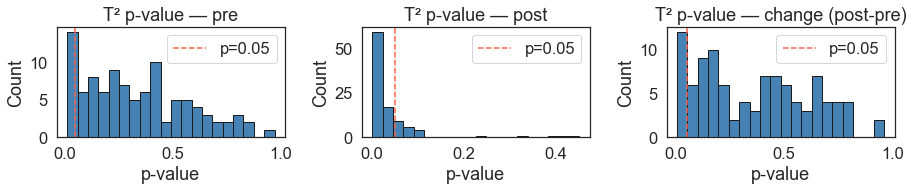

In [16]:
ev_all = np.empty([5, Nsj, 2])
pp, tt = [], []
for sim_idx in range(Nsim):
    for sj in range(Nsj):
        for time_idx in range(2):
            rec_kf   = data[sj]['recovery'][sim_idx][time_idx]
            params   = extract_kf_parameters(rec_kf)
            eigenvector      = np.abs(params['dominant_eigenvector'])
            ev_all[:,sj,time_idx] = eigenvector
    
    pvalues, tvalues = stats_group_difference(ev_all, df)
    pp.append(pvalues)
    tt.append(tvalues)

pp_arr = np.array(pp)  # shape (Nsim, 3)
tt_arr = np.array(tt)  # shape (Nsim, 3)
labels = ['pre', 'post', 'change (post-pre)']

print("=== Hotelling T² group difference recovery across simulations ===")
for i, label in enumerate(labels):
    p = pp_arr[:, i]
    T = tt_arr[:, i]
    print(f"\n  {label.upper()}")
    print(f"  T²:       mean={np.mean(T):.3f} ± {np.std(T):.3f}")
    print(f"  p < 0.05: {np.mean(p < 0.05)*100:.1f}% of simulations")
    print(f"  p < 0.01: {np.mean(p < 0.01)*100:.1f}% of simulations")
    print(f"  median p: {np.median(p):.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for i, (label, ax) in enumerate(zip(labels, axes)):
    ax.hist(pp_arr[:, i], bins=20, edgecolor='k', color='steelblue')
    ax.axvline(0.05, color='tomato', linestyle='--', label='p=0.05')
    ax.set_xlabel("p-value")
    ax.set_ylabel("Count")
    ax.set_title(f"T² p-value — {label}")
    ax.legend()
plt.tight_layout()
plt.show()